# K-Medoids кластеризація

In [20]:
from collections import defaultdict
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np

Point = tuple[int, int]

def manhattan_distance(p1: Point, p2: Point) -> float:
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

In [21]:
class KMedoids:
    distances: dict[str, Callable] = {
        "manhattan": manhattan_distance,
    }

    def __init__(self, data: list[Point], initial_medoids: list[Point], distance_metric: Optional[str] = None):
        self.data = data
        self.medoids = initial_medoids
        self.distance = self.distances.get(distance_metric, manhattan_distance)
        self.clusters: dict[Point, list[Point]] = {}

    def assign_clusters(self) -> dict[Point, list[Point]]:
        clusters = defaultdict(list)
        for point in self.data:
            distances = [self.distance(point, medoid) for medoid in self.medoids]
            closest = self.medoids[np.argmin(distances)]
            clusters[closest].append(point)
        return clusters

    def compute_total_cost(self, cluster: list[Point], medoid: Point) -> int:
        return sum(self.distance(medoid, point) for point in cluster)

    def update_medoids(self, clusters: dict[Point, list[Point]]) -> list[Point]:
        new_medoids = []
        for points in clusters.values():
            costs = [sum(self.distance(p, other) for other in points) for p in points]
            new_medoids.append(points[np.argmin(costs)])
        return new_medoids

    def fit(self, iterations: int, verbose: bool = False) -> None:
        for i in range(iterations):
            self.clusters = self.assign_clusters()
            self.medoids = self.update_medoids(self.clusters)

            if verbose:
                print(f"\nІтерація {i + 1}")
                for medoid, points in clusters.items():
                    print(f"Кластер з центром {medoid}: {points}")
                print(f"Нові медоїди: {self.medoids}")

    def plot(self) -> None:
        plt.figure(figsize=(6, 5))
        for idx, (medoid, points) in enumerate(self.clusters.items()):
            points_arr = np.array(points)
            plt.scatter(points_arr[:, 0], points_arr[:, 1], label=f'Кластер {idx + 1}')
            plt.scatter(*medoid, c='black', marker='X', s=200, edgecolors='white', linewidths=2)
        plt.title('Результат кластеризації')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


Ітерація 1
Кластер з центром (3, 4): [(3, 4), (2, 3), (3, 2), (2, 5)]
Кластер з центром (5, 5): [(7, 4), (5, 5), (6, 6)]
Нові медоїди: [(3, 4), (5, 5)]

Ітерація 2
Кластер з центром (3, 4): [(3, 4), (2, 3), (3, 2), (2, 5)]
Кластер з центром (5, 5): [(7, 4), (5, 5), (6, 6)]
Нові медоїди: [(3, 4), (5, 5)]


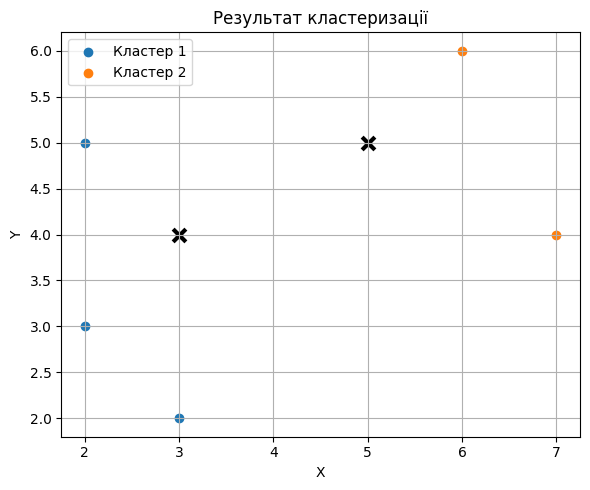

In [22]:
model = KMedoids(
    data=[(3, 4), (7, 4), (2, 3), (3, 2), (5, 5), (6, 6), (2, 5)],
    initial_medoids=[(2, 5), (5, 5)]
)
model.fit(iterations=2, verbose=True)
model.plot()